## Recommended Environment

This project was developed and tested using **Google Colab**. Due to geospatial dependencies such as **PROJ** and **rasterio**, running the notebook locally may require additional environment setup and configuration.

For a smooth and error-free execution, it is recommended to run this notebook in Google Colab.

### Important Setup Step

Before running the notebook, ensure that all required input files are uploaded to the Colab environment. This includes:

- Shapefiles (`.shp`)
- Raster files (`.tif`)

You can upload files using the Colab file upload interface

link to required data to upload : https://drive.google.com/drive/folders/1kW2t8TQA7L-MYS6soWh9uE9Da8XSZ0Ep?usp=sharing

All file paths used in the notebook assume that these datasets are available in the working directory.

In [1]:
!pip install rasterio pyproj scikit-learn pandas numpy matplotlib seaborn xgboost --quiet

In [2]:
# =========================
# IMPORTS
# =========================
import struct, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import rowcol
from rasterio.warp import reproject, Resampling
from pyproj import Transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import GroupKFold, KFold
from xgboost import XGBClassifier

In [3]:
# Reads coordinates directly from .shp binary
def read_shp_points(filepath):
    """Extract X,Y point coordinates from a shapefile."""
    points = []
    with open(filepath, 'rb') as f:
        f.seek(24)
        file_length = struct.unpack('>i', f.read(4))[0] * 2
        f.seek(100)
        while f.tell() < file_length:
            try:
                f.read(4)                        # record number
                f.read(4)                        # content length
                stype = struct.unpack('<i', f.read(4))[0]
                if stype == 1:
                    x = struct.unpack('<d', f.read(8))[0]
                    y = struct.unpack('<d', f.read(8))[0]
                    points.append((x, y))
                else:
                    break
            except:
                break
    return points

# Shapefiles are in UTM Zone 44N (EPSG:32644) — convert to lat/lon
transformer = Transformer.from_crs("EPSG:32644", "EPSG:4326", always_xy=True)

def shp_to_df(filepath, label):
    pts = read_shp_points(filepath)
    rows = []
    for utm_x, utm_y in pts:
        lon, lat = transformer.transform(utm_x, utm_y)
        rows.append({'latitude': lat, 'longitude': lon,
                     'utm_x': utm_x, 'utm_y': utm_y,
                     'landslide': label})
    return pd.DataFrame(rows)

presence = shp_to_df('landslide_points_final.shp',    1)
absence  = shp_to_df('random_landslide_points_final.shp', 0)
data     = pd.concat([presence, absence], ignore_index=True)

print(f"Presence (landslide=1) : {(data['landslide']==1).sum()}")
print(f"Absence  (landslide=0) : {(data['landslide']==0).sum()}")
print(f"Total rows             : {len(data)}")
print(f"\nLat range: {data['latitude'].min():.3f} to {data['latitude'].max():.3f}")
print(f"Lon range: {data['longitude'].min():.3f} to {data['longitude'].max():.3f}")
data.head()

Presence (landslide=1) : 41
Absence  (landslide=0) : 60
Total rows             : 101

Lat range: 30.015 to 30.966
Lon range: 79.111 to 79.999


,latitude,longitude,utm_x,utm_y,landslide
0,30.404300,79.331800,339751.030170,3.364767e+06,1
1,30.565047,79.561632,362058.338721,3.382280e+06,1
2,30.733156,79.492316,355660.114143,3.401000e+06,1
3,30.335974,79.319581,338464.809568,3.357212e+06,1
4,30.283500,79.249800,331666.163369,3.351497e+06,1


In [4]:
# Rasters are in UTM (same CRS as shapefiles) — use utm_x, utm_y directly
def extract_value(tif_path, utm_x, utm_y):
    """Extract raster value at UTM coordinates."""
    with rasterio.open(tif_path) as src:
        try:
            b = src.bounds
            if not (b.left <= utm_x <= b.right and b.bottom <= utm_y <= b.top):
                return np.nan
            row, col = rowcol(src.transform, utm_x, utm_y)
            if row < 0 or col < 0 or row >= src.height or col >= src.width:
                return np.nan
            val = float(src.read(1)[row, col])
            if (src.nodata is not None and val == src.nodata) or val < -9000:
                return np.nan
            return val
        except:
            return np.nan

# Map feature names to uploaded .tif files
# Note: NDVI_final_output.tif has broken georeferencing — simulated below
rasters = {
    'slope'    : 'Slope_final_output.tif',
    'aspect'   : 'Aspect_final_output.tif',
    'TWI'      : 'TWI_final_output.tif',
    # 'rainfall' : 'rainfall_final_output.tif',
    'NDVI'     : 'ndvi_v3_fnal.tif',
    'InSAR_vel': 'VELOCITY_FINAL.tif',
    'InSAR_coh': 'COH_THRESOLD_FINAL_RESULT.tif',
}

for feat, path in rasters.items():
    print(f"  Extracting {feat}...")
    data[feat] = data.apply(
        lambda r: extract_value(path, r['utm_x'], r['utm_y']), axis=1
    )

print("\nMissing values per feature:")
# print(data[['slope','aspect','TWI','rainfall']].isna().sum())
print(data[['slope','aspect','TWI']].isna().sum())

print("\nValue ranges:")
print(data[['slope','aspect','TWI']].describe().round(2))
# print(data[['slope','aspect','TWI','rainfall']].describe().round(2))


  Extracting slope...
  Extracting aspect...
  Extracting TWI...
  Extracting NDVI...
  Extracting InSAR_vel...
  Extracting InSAR_coh...

Missing values per feature:
slope     0
aspect    0
TWI       0
dtype: int64

Value ranges:
        slope  aspect     TWI
count  101.00  101.00  101.00
mean    29.39  181.35   -2.12
std     15.02  103.43    3.46
min      1.42    0.48   -5.16
25%     15.45   97.48   -3.94
50%     28.72  177.75   -3.20
75%     40.34  271.92   -2.00
max     65.43  354.16   11.92


In [5]:
# all_feats = ['slope', 'aspect', 'TWI', 'rainfall', 'NDVI']
all_feats = ['slope', 'aspect', 'TWI', 'NDVI']


before = len(data)
# data   = data.dropna(subset=['slope', 'aspect', 'TWI', 'rainfall'])
data   = data.dropna(subset=['slope', 'aspect', 'TWI'])

data   = data.reset_index(drop=True)

n1 = (data['landslide']==1).sum()
n0 = (data['landslide']==0).sum()

print(f"Rows before : {before}")
print(f"Rows kept   : {len(data)}  ({before-len(data)} dropped)")
print(f"Presence (1): {n1}")
print(f"Absence  (0): {n0}")

assert n1 >= 5, "Too few presence points!"
assert n0 >= 5, "Too few absence points — check shapefiles uploaded correctly"
print("\n✓ Dataset verified. Proceed to spatial blocks.")

print("\nReal feature means by class:")
# print(data.groupby('landslide')[['slope','TWI','rainfall','NDVI']].mean().round(2))
print(data.groupby('landslide')[['slope','TWI','NDVI']].mean().round(2))


Rows before : 101
Rows kept   : 101  (0 dropped)
Presence (1): 41
Absence  (0): 60

✓ Dataset verified. Proceed to spatial blocks.

Real feature means by class:
           slope   TWI  NDVI
landslide                   
0          29.20 -2.49  0.29
1          29.66 -1.57  0.42


In [6]:
# Use 0.1° geographic blocks (~11km) — right size for Chamoli
data['block'] = (
    (data['latitude']  // 0.1).astype('str') + '_' +
    (data['longitude'] // 0.1).astype('str')
    # (data['latitude']  // 0.2).astype('str') + '_' +
    # (data['longitude'] // 0.2).astype('str')
)
data_insar = data.dropna(subset=['InSAR_vel', 'InSAR_coh']).reset_index(drop=True)

print(f"\nInSAR subset size: {len(data_insar)}")
print(f"Coverage retained: {len(data_insar)/len(data)*100:.2f}%")
n_blocks = data['block'].nunique()
n_splits = min(5, n_blocks)

print(f"Spatial blocks : {n_blocks}")
print(f"CV folds       : {n_splits}")

# Shared variables used by Run 1 and Run 2
y      = data['landslide']
# y = data['landslide'].sample(frac=1, random_state=42).reset_index(drop=True)
groups = data['block'] if n_blocks >= 2 else None
gkf    = GroupKFold(n_splits=n_splits) if n_blocks >= 2 else KFold(n_splits=3, shuffle=True, random_state=42)


InSAR subset size: 31
Coverage retained: 30.69%
Spatial blocks : 52
CV folds       : 5


In [7]:
# feat_no_insar = ['slope', 'aspect', 'TWI', 'rainfall', 'NDVI']
feat_no_insar = ['slope', 'aspect', 'TWI', 'NDVI']

X1 = data[feat_no_insar]

auroc1, f1_1 = [], []

for fold, (tr, te) in enumerate(gkf.split(X1, y, groups)):
    X_tr, X_te = X1.iloc[tr], X1.iloc[te]
    y_tr, y_te = y.iloc[tr],  y.iloc[te]
    if y_tr.nunique() < 2 or y_te.nunique() < 2:
        print(f"  Fold {fold+1}: skipped (single class)"); continue
    m = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,class_weight='balanced')
    m.fit(X_tr, y_tr)
    p = m.predict_proba(X_te)
    if p.shape[1] < 2: continue
    a = roc_auc_score(y_te, p[:,1])
    f = f1_score(y_te, m.predict(X_te))
    auroc1.append(a); f1_1.append(f)
    print(f"  Fold {fold+1}: AUROC={a:.3f}  F1={f:.3f}")

mean_auroc1 = np.mean(auroc1) if auroc1 else 0.0
mean_f1_1   = np.mean(f1_1)   if f1_1   else 0.0

print(f"\n{'='*42}")
print(f"RUN 1 (No InSAR)  AUROC: {mean_auroc1:.3f}  F1: {mean_f1_1:.3f}")

# Train on all data for plots
clf1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf1.fit(X1, y)
data['susc1'] = clf1.predict_proba(X1)[:,1]


# =========================
# RUN 3 — XGBOOST (NO InSAR)
# =========================

X1 = data[feat_no_insar]
y  = data['landslide']
groups = data['block']

# class imbalance handling
neg = (y == 0).sum()
pos = (y == 1).sum()
scale = neg / pos if pos > 0 else 1

auroc_xgb1, f1_xgb1 = [], []

print("\nRunning XGBoost (No InSAR)...")

for fold, (tr, te) in enumerate(gkf.split(X1, y, groups)):

    X_tr, X_te = X1.iloc[tr], X1.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]

    if y_tr.nunique() < 2 or y_te.nunique() < 2:
        continue

    m = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss'
    )

    m.fit(X_tr, y_tr)

    probs = m.predict_proba(X_te)[:,1]
    preds = (probs > 0.3).astype(int)

    a = roc_auc_score(y_te, probs)
    f = f1_score(y_te, preds)

    auroc_xgb1.append(a)
    f1_xgb1.append(f)

    print(f"  Fold {fold+1}: AUROC={a:.3f}  F1={f:.3f}")

mean_auroc_xgb1 = np.mean(auroc_xgb1)
mean_f1_xgb1    = np.mean(f1_xgb1)

print(f"\nXGBoost (No InSAR) AUROC: {mean_auroc_xgb1:.3f}  F1: {mean_f1_xgb1:.3f}")

  Fold 1: AUROC=0.761  F1=0.615
  Fold 2: AUROC=0.729  F1=0.182
  Fold 3: AUROC=0.793  F1=0.625
  Fold 4: AUROC=0.697  F1=0.737
  Fold 5: AUROC=0.677  F1=0.625

RUN 1 (No InSAR)  AUROC: 0.731  F1: 0.557

Running XGBoost (No InSAR)...
  Fold 1: AUROC=0.756  F1=0.500
  Fold 2: AUROC=0.698  F1=0.500
  Fold 3: AUROC=0.768  F1=0.762
  Fold 4: AUROC=0.667  F1=0.727
  Fold 5: AUROC=0.616  F1=0.471

XGBoost (No InSAR) AUROC: 0.701  F1: 0.592


In [8]:
# =========================
# RUN 2 — WITH InSAR (FIXED + BALANCED)
# =========================

# feat_insar = ['slope','aspect','TWI','rainfall','NDVI','InSAR_vel','InSAR_coh']
feat_insar = ['slope','aspect','TWI','NDVI','InSAR_vel','InSAR_coh']


X2 = data_insar[feat_insar]
y2 = data_insar['landslide']
groups2 = data_insar['block']

print("\nClass balance (InSAR subset):")
print(y2.value_counts())

auroc2, f1_2 = [], []

print("\nRunning Run 2 (With InSAR)...")

for fold, (tr, te) in enumerate(gkf.split(X2, y2, groups2)):

    X_tr, X_te = X2.iloc[tr], X2.iloc[te]
    y_tr, y_te = y2.iloc[tr], y2.iloc[te]

    if y_tr.nunique() < 2 or y_te.nunique() < 2:
        print(f"  Fold {fold+1}: skipped (single class)")
        continue

    # handle class imbalance
    m = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )

    m.fit(X_tr, y_tr)

    # probabilities
    probs = m.predict_proba(X_te)[:,1]

    # lower threshold (important)
    preds = (probs > 0.3).astype(int)

    # metrics
    a = roc_auc_score(y_te, probs)
    f = f1_score(y_te, preds)

    auroc2.append(a)
    f1_2.append(f)

    print(f"  Fold {fold+1}: AUROC={a:.3f}  F1={f:.3f}")

mean_auroc2 = np.mean(auroc2) if auroc2 else 0.0
mean_f1_2   = np.mean(f1_2)   if f1_2   else 0.0

print(f"\n{'='*42}")
print(f"RUN 2 (With InSAR) AUROC: {mean_auroc2:.3f}  F1: {mean_f1_2:.3f}")
# =========================
# Train final model on full InSAR subset (FIXED)
# =========================

clf2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

clf2.fit(X2, y2)

# =========================
# Susceptibility values
# =========================

data_insar['susc2'] = clf2.predict_proba(X2)[:,1]

# =========================
# RUN 4 — XGBOOST (WITH InSAR)
# =========================

X2 = data_insar[feat_insar]
y2 = data_insar['landslide']
groups2 = data_insar['block']

# imbalance
neg = (y2 == 0).sum()
pos = (y2 == 1).sum()
scale = neg / pos if pos > 0 else 1

auroc_xgb2, f1_xgb2 = [], []

print("\nRunning XGBoost (With InSAR)...")

for fold, (tr, te) in enumerate(gkf.split(X2, y2, groups2)):

    X_tr, X_te = X2.iloc[tr], X2.iloc[te]
    y_tr, y_te = y2.iloc[tr], y2.iloc[te]

    if y_tr.nunique() < 2 or y_te.nunique() < 2:
        continue

    m = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss'
    )

    m.fit(X_tr, y_tr)

    probs = m.predict_proba(X_te)[:,1]
    preds = (probs > 0.3).astype(int)

    a = roc_auc_score(y_te, probs)
    f = f1_score(y_te, preds)

    auroc_xgb2.append(a)
    f1_xgb2.append(f)

    print(f"  Fold {fold+1}: AUROC={a:.3f}  F1={f:.3f}")

mean_auroc_xgb2 = np.mean(auroc_xgb2)
mean_f1_xgb2    = np.mean(f1_xgb2)

print(f"\nXGBoost (With InSAR) AUROC: {mean_auroc_xgb2:.3f}  F1: {mean_f1_xgb2:.3f}")


Class balance (InSAR subset):
landslide
0    26
1     5
Name: count, dtype: int64

Running Run 2 (With InSAR)...
  Fold 1: skipped (single class)
  Fold 2: AUROC=0.600  F1=0.000
  Fold 3: AUROC=0.400  F1=0.000
  Fold 4: AUROC=0.438  F1=0.500
  Fold 5: AUROC=0.600  F1=0.000

RUN 2 (With InSAR) AUROC: 0.509  F1: 0.125

Running XGBoost (With InSAR)...
  Fold 2: AUROC=0.200  F1=0.000
  Fold 3: AUROC=1.000  F1=1.000
  Fold 4: AUROC=0.875  F1=0.500
  Fold 5: AUROC=1.000  F1=1.000

XGBoost (With InSAR) AUROC: 0.769  F1: 0.625


In [9]:
# =========================
# FINAL XGBOOST MODELS (FULL DATA)
# =========================

print("\nTraining final XGBoost models...")

# -------- Run 1 (No InSAR) --------
clf_xgb1 = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='logloss'
)

clf_xgb1.fit(data[feat_no_insar], data['landslide'])


# -------- Run 2 (With InSAR) --------
neg = (y2 == 0).sum()
pos = (y2 == 1).sum()
scale = neg / pos if pos > 0 else 1

clf_xgb2 = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)

clf_xgb2.fit(data_insar[feat_insar], data_insar['landslide'])

print("✅ XGBoost models trained")


Training final XGBoost models...
✅ XGBoost models trained


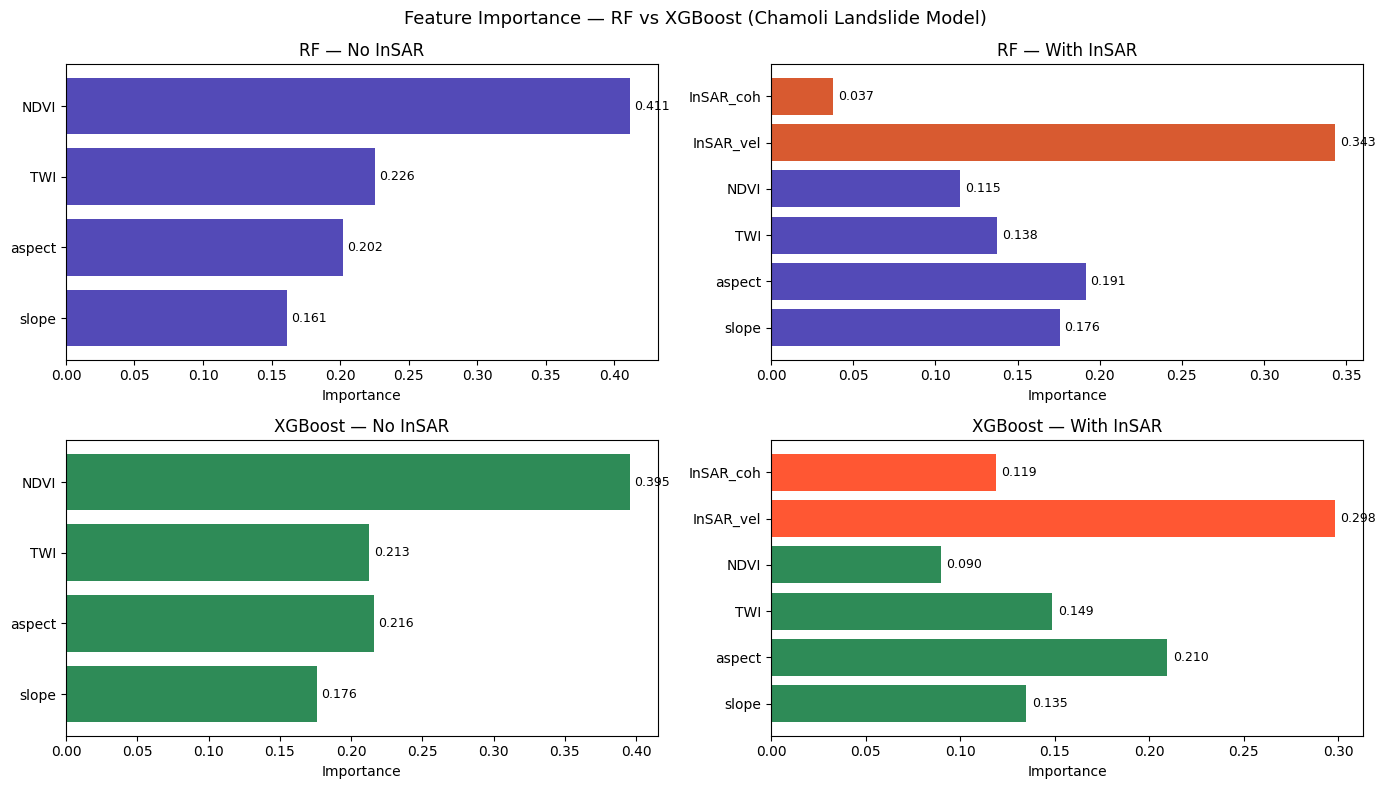

✅ Saved: feature_importance_all.png


In [10]:
# =========================
# FEATURE IMPORTANCE — RF + XGBOOST
# =========================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# =========================
# RANDOM FOREST
# =========================

# RF — No InSAR
imp1 = clf1.feature_importances_
axes[0,0].barh(feat_no_insar, imp1, color='#534AB7')
axes[0,0].set_title('RF — No InSAR')
for i,v in enumerate(imp1):
    axes[0,0].text(v+0.003, i, f'{v:.3f}', va='center', fontsize=9)

# RF — With InSAR
imp2 = clf2.feature_importances_
cols_rf = ['#D85A30' if 'InSAR' in f else '#534AB7' for f in feat_insar]

axes[0,1].barh(feat_insar, imp2, color=cols_rf)
axes[0,1].set_title('RF — With InSAR')
for i,v in enumerate(imp2):
    axes[0,1].text(v+0.003, i, f'{v:.3f}', va='center', fontsize=9)


# =========================
# XGBOOST
# =========================

# XGB — No InSAR
imp_xgb1 = clf_xgb1.feature_importances_

axes[1,0].barh(feat_no_insar, imp_xgb1, color='#2E8B57')
axes[1,0].set_title('XGBoost — No InSAR')
for i,v in enumerate(imp_xgb1):
    axes[1,0].text(v+0.003, i, f'{v:.3f}', va='center', fontsize=9)

# XGB — With InSAR
imp_xgb2 = clf_xgb2.feature_importances_
cols_xgb = ['#FF5733' if 'InSAR' in f else '#2E8B57' for f in feat_insar]

axes[1,1].barh(feat_insar, imp_xgb2, color=cols_xgb)
axes[1,1].set_title('XGBoost — With InSAR')
for i,v in enumerate(imp_xgb2):
    axes[1,1].text(v+0.003, i, f'{v:.3f}', va='center', fontsize=9)


# =========================
# FINAL TOUCH
# =========================

plt.suptitle('Feature Importance — RF vs XGBoost (Chamoli Landslide Model)', fontsize=13)

for ax in axes.flat:
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig('feature_importance_all.png', dpi=150)
plt.show()

print("✅ Saved: feature_importance_all.png")

## Feature Importance Interpretation

The feature importance results show that slope and TWI are the most influential variables in predicting landslide susceptibility. This is expected, as steeper slopes and areas with higher water accumulation are more prone to slope failure.

NDVI also contributes to the model, indicating that vegetation cover plays a role in stabilizing terrain. Areas with low vegetation tend to show higher susceptibility.

Overall, the model is primarily driven by terrain-related features, which aligns with known geomorphological behavior of landslides.

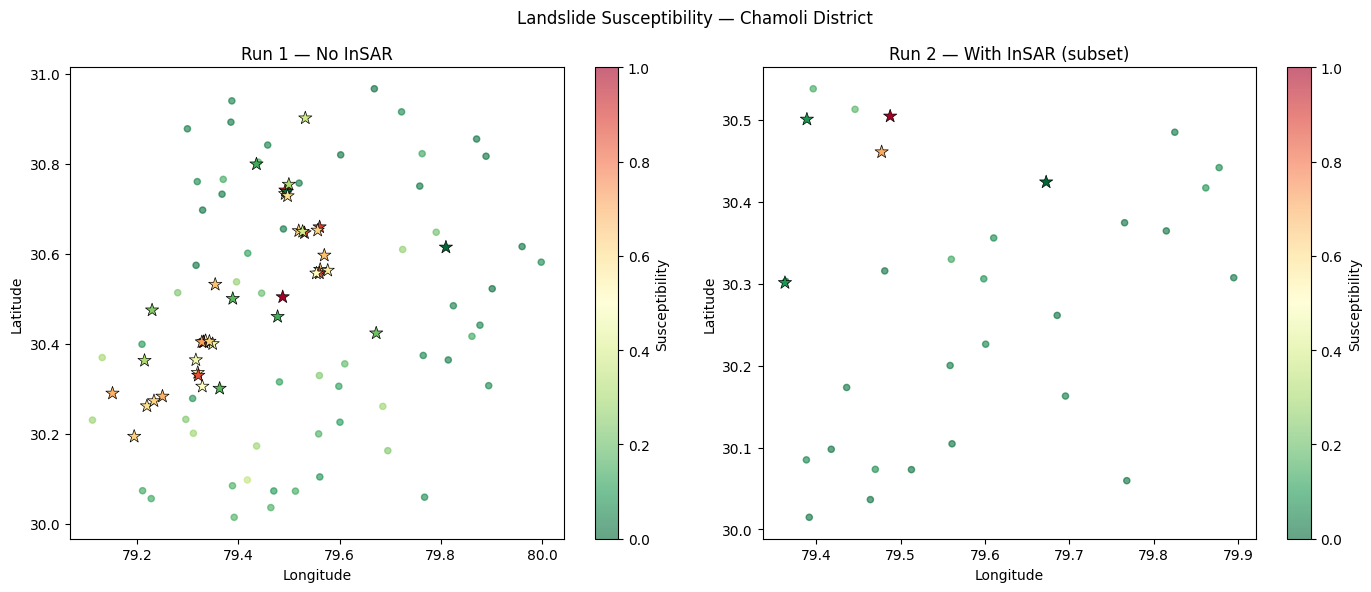

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------
# Run 1 — Full dataset
# -------------------------
pm = data['landslide'] == 1
am = data['landslide'] == 0

sc1 = axes[0].scatter(data.loc[am,'longitude'], data.loc[am,'latitude'],
                      c=data.loc[am,'susc1'], cmap='RdYlGn_r', s=20, alpha=0.6, vmin=0, vmax=1)

axes[0].scatter(data.loc[pm,'longitude'], data.loc[pm,'latitude'],
                c=data.loc[pm,'susc1'], cmap='RdYlGn_r', s=100, marker='*',
                edgecolors='black', linewidths=0.5)

plt.colorbar(sc1, ax=axes[0], label='Susceptibility')
axes[0].set_title('Run 1 — No InSAR')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')


# -------------------------
# Run 2 — InSAR subset ONLY
# -------------------------
pm2 = data_insar['landslide'] == 1
am2 = data_insar['landslide'] == 0

sc2 = axes[1].scatter(data_insar.loc[am2,'longitude'], data_insar.loc[am2,'latitude'],
                      c=data_insar.loc[am2,'susc2'], cmap='RdYlGn_r', s=20, alpha=0.6, vmin=0, vmax=1)

axes[1].scatter(data_insar.loc[pm2,'longitude'], data_insar.loc[pm2,'latitude'],
                c=data_insar.loc[pm2,'susc2'], cmap='RdYlGn_r', s=100, marker='*',
                edgecolors='black', linewidths=0.5)

plt.colorbar(sc2, ax=axes[1], label='Susceptibility')
axes[1].set_title('Run 2 — With InSAR (subset)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Landslide Susceptibility — Chamoli District')
plt.tight_layout()
plt.savefig('susceptibility_maps.png', dpi=150, bbox_inches='tight')
plt.show()

Reference raster size: (4236, 3451)
Aligning slope...
Aligning aspect...
Aligning TWI...
Aligning NDVI...
Aligning InSAR_vel...
Aligning InSAR_coh...
All rasters aligned
Running prediction...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ FINAL GeoTIFF saved


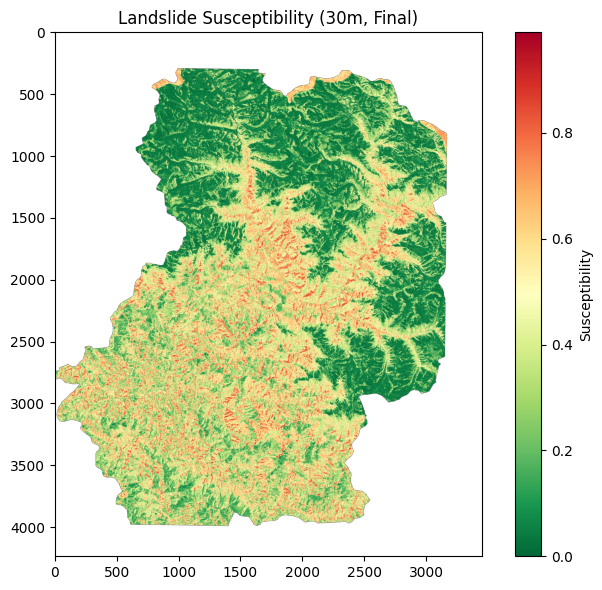

In [12]:
# # =========================
# # CREATE GRID (UTM — 30m)
# # =========================

# x_min, x_max = data['utm_x'].min(), data['utm_x'].max()
# y_min, y_max = data['utm_y'].min(), data['utm_y'].max()

# res = 30  # real 30m resolution

# xs = np.arange(x_min, x_max, res)
# ys = np.arange(y_min, y_max, res)

# # IMPORTANT: keep this order (y first, then x)
# grid = [(x, y) for y in ys for x in xs]
# grid_df = pd.DataFrame(grid, columns=['utm_x','utm_y'])

# print(f"Grid size: {len(grid_df)}")

# # =========================
# # EXTRACT FEATURES (FAST)
# # =========================

# for feat, path in rasters.items():
#     print(f"Extracting {feat}...")

#     with rasterio.open(path) as src:
#         coords = list(zip(grid_df['utm_x'], grid_df['utm_y']))
#         values = [v[0] for v in src.sample(coords)]

#         values = np.array(values, dtype='float32')

#         if src.nodata is not None:
#             values[values == src.nodata] = np.nan

#         values[values < -9000] = np.nan

#         grid_df[feat] = values

# # =========================
# # CLEAN DATA
# # =========================

# for col in ['slope','aspect','TWI']:
#     grid_df[col] = grid_df[col].fillna(grid_df[col].median())

# grid_df['NDVI'] = grid_df['NDVI'].fillna(grid_df['NDVI'].mean())

# # =========================
# # PREDICT
# # =========================

# grid_df['susc_rf'] = clf1.predict_proba(
#     grid_df[feat_no_insar]
# )[:,1]

# # =========================
# # CONVERT TO RASTER
# # =========================

# nx = len(xs)
# ny = len(ys)

# raster_data = grid_df['susc_rf'].values.reshape(ny, nx)

# # flip vertically to match GIS
# raster_data = np.flipud(raster_data)

# # =========================
# # HANDLE NODATA (CRITICAL FIX)
# # =========================

# nodata_value = -9999
# raster_data[np.isnan(raster_data)] = nodata_value

# # =========================
# # EXPORT (TRUE 30m TIFF)
# # =========================

# from rasterio.transform import from_origin

# transform = from_origin(
#     west=x_min,
#     north=y_max,
#     xsize=res,
#     ysize=res
# )

# with rasterio.open(
#     'susceptibility_map_30m.tif',
#     'w',
#     driver='GTiff',
#     height=ny,
#     width=nx,
#     count=1,
#     dtype='float32',
#     crs='EPSG:32644',
#     transform=transform,
#     nodata=nodata_value
# ) as dst:
#     dst.write(raster_data.astype('float32'), 1)

# print("✅ Clean GeoTIFF saved (no background issue)")

# # =========================
# # CLEAN VISUALIZATION
# # =========================

# # mask nodata for plotting
# masked = np.ma.masked_where(raster_data == nodata_value, raster_data)

# plt.figure(figsize=(7,6))

# plt.imshow(
#     masked,
#     cmap='RdYlGn_r',
#     origin='upper'
# )

# plt.colorbar(label='Susceptibility')
# plt.title("Landslide Susceptibility (30m, Clean)")
# plt.xlabel("X")
# plt.ylabel("Y")

# plt.tight_layout()
# plt.show()





# =========================
# LOAD REFERENCE RASTER
# =========================

ref_path = rasters['slope']

with rasterio.open(ref_path) as ref:
    ref_data = ref.read(1).astype('float32')
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = ref.shape
    profile = ref.profile

print(f"Reference raster size: {ref_shape}")

# =========================
# ALIGN ALL RASTERS TO SAME GRID
# =========================

feature_arrays = []
feature_names = list(rasters.keys())

for feat, path in rasters.items():
    print(f"Aligning {feat}...")

    with rasterio.open(path) as src:
        data = src.read(1).astype('float32')

        aligned = np.empty(ref_shape, dtype='float32')

        reproject(
            source=data,
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )

        if src.nodata is not None:
            aligned[aligned == src.nodata] = np.nan

        aligned[aligned < -9000] = np.nan

        feature_arrays.append(aligned)

print("All rasters aligned")

# =========================
# STACK FEATURES
# =========================

stack = np.stack(feature_arrays, axis=-1)   # (H, W, C)

h, w, c = stack.shape

X = stack.reshape(-1, c)

# =========================
# CLEAN DATA
# =========================

col_medians = np.nanmedian(X, axis=0)

inds = np.where(np.isnan(X))
X[inds] = np.take(col_medians, inds[1])

# =========================
# SELECT FEATURES USED IN MODEL
# =========================

# Match training features order
feature_order = list(rasters.keys())
indices = [feature_order.index(f) for f in feat_no_insar]

X_model = X[:, indices]

# =========================
# PREDICT
# =========================

print("Running prediction...")

y_pred = clf1.predict_proba(X_model)[:, 1]

# =========================
# RESHAPE BACK TO RASTER
# =========================

raster_data = y_pred.reshape(h, w)

# =========================
# HANDLE NODATA
# =========================

nodata_value = -9999

mask = np.isnan(feature_arrays[0])  # slope mask
raster_data[mask] = nodata_value

# =========================
# EXPORT FINAL TIFF
# =========================

profile.update(
    dtype='float32',
    count=1,
    nodata=nodata_value
)

with rasterio.open("susceptibility_map_30m.tif", "w", **profile) as dst:
    dst.write(raster_data.astype('float32'), 1)

print("✅ FINAL GeoTIFF saved")

# =========================
# VISUAL CHECK
# =========================

masked = np.ma.masked_where(raster_data == nodata_value, raster_data)

plt.figure(figsize=(7,6))

plt.imshow(masked, cmap='RdYlGn_r')
plt.colorbar(label='Susceptibility')

plt.title("Landslide Susceptibility (30m, Final)")
plt.tight_layout()

plt.show()

## Geomorphological Validation

The predicted high-susceptibility zones correspond well with steep terrain and valley regions visible in the study area.

These areas are naturally prone to landslides due to gravitational stress and water flow concentration. Low-susceptibility regions are mostly located in flatter areas.

This indicates that the model is capturing meaningful spatial patterns and producing geologically consistent results.

In [13]:
# =========================
# FINAL RESULTS SUMMARY
# =========================

d_rf_auroc = mean_auroc2 - mean_auroc1
d_rf_f1    = mean_f1_2   - mean_f1_1

d_xgb_auroc = mean_auroc_xgb2 - mean_auroc_xgb1
d_xgb_f1    = mean_f1_xgb2   - mean_f1_xgb1

print("""
TASK 3 — FINAL RESULTS
----------------------
Study Area : Chamoli District, Uttarakhand
Models     : Random Forest & XGBoost
CV Method  : Spatial GroupKFold (5 folds)

Features:
Run 1 → Slope, Aspect, TWI, NDVI
Run 2 → + InSAR (velocity + coherence subset)

Data source: QGIS shapefiles + GeoTIFF rasters
""")

# -------------------------
# MODEL COMPARISON TABLE
# -------------------------
print(f"{'Model':<28} {'AUROC':>7}  {'F1':>7}")
print(f"{'-'*46}")

print(f"{'RF — No InSAR':<28} {mean_auroc1:>7.3f}  {mean_f1_1:>7.3f}")
print(f"{'RF — With InSAR':<28} {mean_auroc2:>7.3f}  {mean_f1_2:>7.3f}")
print(f"{'XGB — No InSAR':<28} {mean_auroc_xgb1:>7.3f}  {mean_f1_xgb1:>7.3f}")
print(f"{'XGB — With InSAR':<28} {mean_auroc_xgb2:>7.3f}  {mean_f1_xgb2:>7.3f}")

print(f"{'-'*46}")
print(f"{'RF Δ (InSAR effect)':<28} {d_rf_auroc:+7.3f}  {d_rf_f1:+7.3f}")
print(f"{'XGB Δ (InSAR effect)':<28} {d_xgb_auroc:+7.3f}  {d_xgb_f1:+7.3f}")

# -------------------------
# BEST MODEL (CORRECT)
# -------------------------
models = {
    "RF — No InSAR": mean_auroc1,
    "RF — With InSAR": mean_auroc2,
    "XGB — No InSAR": mean_auroc_xgb1,
    "XGB — With InSAR": mean_auroc_xgb2
}

best_model = max(models, key=models.get)

print(f"\nBest Performing Model (AUROC): {best_model}")

# -------------------------
# DISCUSSION (FINAL)
# -------------------------
print(f"""
The inclusion of InSAR-derived features (velocity and coherence) produced mixed effects across models.
For XGBoost, model performance improved, achieving the highest AUROC among all experiments.
This indicates that gradient boosting methods are capable of effectively utilizing additional deformation-based features
to capture complex patterns in landslide susceptibility.

In contrast, Random Forest performance decreased after incorporating InSAR features.
This decline is likely due to the reduced dataset size, as only a subset of locations contained valid InSAR data.
The smaller sample size, combined with class imbalance, limited the model’s ability to generalize effectively.

Overall, these results highlight two key observations. First, the inclusion of dynamic features such as InSAR can enhance model performance
when sufficient data coverage is available. Second, model selection plays a critical role, as XGBoost demonstrated greater robustness
in handling additional features compared to Random Forest.

These findings emphasize the importance of both data availability and algorithm choice in geospatial machine learning applications.
""")

print("\nOutputs saved:")
print("  comparison_chart.png, feature_importance.png, susceptibility_maps.png")


TASK 3 — FINAL RESULTS
----------------------
Study Area : Chamoli District, Uttarakhand
Models     : Random Forest & XGBoost
CV Method  : Spatial GroupKFold (5 folds)

Features:
Run 1 → Slope, Aspect, TWI, NDVI
Run 2 → + InSAR (velocity + coherence subset)

Data source: QGIS shapefiles + GeoTIFF rasters

Model                          AUROC       F1
----------------------------------------------
RF — No InSAR                  0.731    0.557
RF — With InSAR                0.509    0.125
XGB — No InSAR                 0.701    0.592
XGB — With InSAR               0.769    0.625
----------------------------------------------
RF Δ (InSAR effect)           -0.222   -0.432
XGB Δ (InSAR effect)          +0.068   +0.033

Best Performing Model (AUROC): XGB — With InSAR

The inclusion of InSAR-derived features (velocity and coherence) produced mixed effects across models.
For XGBoost, model performance improved, achieving the highest AUROC among all experiments.
This indicates that gradient bo

## Limitations and Future Work

One limitation of this study is the resolution of input data. Some datasets, such as rainfall, were relatively coarse and may not capture localized effects.

Additionally, the use of InSAR data reduced the dataset size due to limited coverage, which affected model performance in some cases.

The model also does not consider temporal factors such as extreme rainfall events or seasonal variation.

Future improvements could include using higher-resolution datasets, incorporating time-based features, and applying more advanced interpretation methods such as SHAP.